# Campo de Direções e Soluções de Equações Diferenciais

Este caderno permite explorar **equações diferenciais ordinárias de primeira ordem** da forma:

$$\frac{dy}{dx} = f(x, y)$$

Você poderá:

1. Digitar uma equação diferencial envolvendo as variáveis $x$ e $y$
2. Ajustar os limites do plano cartesiano
3. Visualizar o **campo de direções** — pequenos segmentos que indicam, em cada ponto $(x,y)$, a inclinação da solução que passa por ali
4. Controlar a **densidade** e o **comprimento** dos segmentos
5. Definir uma **condição inicial** $(x_0, y_0)$ e ver a curva-solução correspondente

---

## O que é um campo de direções?

Dada $\frac{dy}{dx} = f(x,y)$, para cada ponto $(x,y)$ do plano, o valor $f(x,y)$ nos diz a **inclinação** da reta tangente à curva-solução naquele ponto. O campo de direções consiste em desenhar, numa grade de pontos, pequenos segmentos com essa inclinação. Isso nos dá uma visão qualitativa do comportamento das soluções **antes mesmo de resolvê-las analiticamente**.

---

## Configuração inicial

Execute a célula abaixo para carregar as bibliotecas necessárias.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## Funções auxiliares

A célula abaixo define as funções que desenham o campo de direções e a curva-solução. Execute-a antes de usar o painel interativo.

In [2]:
def parse_equation(expr_str):
    """
    Converte uma string representando f(x, y) em uma função Python.
    Aceita expressões como: x + y, x**2 - y, sin(x)*y, exp(-x*y), etc.
    """
    # Funções matemáticas disponíveis no escopo da expressão
    safe_dict = {
        'sin': np.sin, 'cos': np.cos, 'tan': np.tan,
        'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt,
        'abs': np.abs, 'pi': np.pi, 'e': np.e,
        'arctan': np.arctan, 'arcsin': np.arcsin, 'arccos': np.arccos,
        'sinh': np.sinh, 'cosh': np.cosh, 'tanh': np.tanh,
    }
    def f(x, y):
        local_dict = {**safe_dict, 'x': x, 'y': y}
        return eval(expr_str, {"__builtins__": {}}, local_dict)
    return f


def draw_direction_field(ax, f, xlim, ylim, density, seg_length):
    """
    Desenha o campo de direções no eixo 'ax'.
    
    Parâmetros:
        f          : função f(x, y) = dy/dx
        xlim, ylim : tuplas (min, max) dos eixos
        density    : número de pontos em cada direção da grade
        seg_length : fator de escala para o comprimento dos segmentos
    """
    xs = np.linspace(xlim[0], xlim[1], density)
    ys = np.linspace(ylim[0], ylim[1], density)
    X, Y = np.meshgrid(xs, ys)
    
    # Calcula as inclinações
    try:
        DY = f(X, Y)
    except Exception:
        DY = np.zeros_like(X)
    
    # Componente horizontal unitária; vertical proporcional à inclinação
    DX = np.ones_like(DY)
    
    # Trata valores infinitos ou NaN
    mask = np.isfinite(DY)
    DX[~mask] = 0
    DY[~mask] = 0
    
    # Normaliza cada vetor para comprimento unitário
    norm = np.sqrt(DX**2 + DY**2)
    norm[norm == 0] = 1
    DX = DX / norm
    DY = DY / norm
    
    # Escala pelo comprimento desejado (proporcional ao espaçamento da grade)
    spacing_x = (xlim[1] - xlim[0]) / density
    spacing_y = (ylim[1] - ylim[0]) / density
    spacing = min(spacing_x, spacing_y)
    scale = seg_length * spacing * 0.45
    
    # Desenha os segmentos centrados em cada ponto da grade
    for i in range(density):
        for j in range(density):
            xi, yi = X[j, i], Y[j, i]
            dxi, dyi = DX[j, i] * scale, DY[j, i] * scale
            ax.plot(
                [xi - dxi/2, xi + dxi/2],
                [yi - dyi/2, yi + dyi/2],
                color='#4A7BA8', linewidth=0.8, alpha=0.7, solid_capstyle='round'
            )


def solve_ode(f, x0, y0, xlim, n_points=1000):
    """
    Resolve a EDO dy/dx = f(x,y) com condição inicial (x0, y0).
    Integra para frente e para trás a partir de x0.
    """
    results_x = []
    results_y = []
    
    # Integração para a direita (x0 -> xlim[1])
    if x0 < xlim[1]:
        t_span_fwd = (x0, xlim[1])
        t_eval_fwd = np.linspace(x0, xlim[1], n_points)
        try:
            sol_fwd = solve_ivp(
                lambda t, y: f(t, y[0]),
                t_span_fwd, [y0], t_eval=t_eval_fwd,
                method='RK45', max_step=0.05, rtol=1e-8, atol=1e-10
            )
            if sol_fwd.success:
                results_x.append(sol_fwd.t)
                results_y.append(sol_fwd.y[0])
        except Exception:
            pass
    
    # Integração para a esquerda (x0 -> xlim[0])
    if x0 > xlim[0]:
        t_span_bwd = (x0, xlim[0])
        t_eval_bwd = np.linspace(x0, xlim[0], n_points)
        try:
            sol_bwd = solve_ivp(
                lambda t, y: f(t, y[0]),
                t_span_bwd, [y0], t_eval=t_eval_bwd,
                method='RK45', max_step=0.05, rtol=1e-8, atol=1e-10
            )
            if sol_bwd.success:
                results_x.insert(0, sol_bwd.t[::-1])
                results_y.insert(0, sol_bwd.y[0][::-1])
        except Exception:
            pass
    
    if results_x:
        all_x = np.concatenate(results_x)
        all_y = np.concatenate(results_y)
        return all_x, all_y
    return None, None


print("Funções definidas com sucesso!")

Funções definidas com sucesso!


## Painel interativo

Execute a célula abaixo para abrir o painel de controle. Você poderá:

- **Equação `dy/dx =`** — digite uma expressão em `x` e `y`. Exemplos:
  - `x + y` (crescimento exponencial misturado)
  - `x**2 - y` (equação linear de primeira ordem)
  - `sin(x) * cos(y)` (campo periódico)
  - `-x / y` (circunferências)
  - `y * (1 - y)` (equação logística autônoma)
  - `x * y` 
  - `-2 * x * y` (família de gaussianas)

- **Limites do plano** — valores mínimos e máximos de $x$ e $y$
- **Densidade** — quantos segmentos por direção na grade
- **Comprimento** — tamanho relativo dos segmentos
- **Condição inicial** — coordenadas $(x_0, y_0)$ e botão para traçar a solução

Funções disponíveis na expressão: `sin`, `cos`, `tan`, `exp`, `log` (natural), `sqrt`, `abs`, `arctan`, `arcsin`, `arccos`, `sinh`, `cosh`, `tanh`, `pi`, `e`.

In [3]:
# ═══════════════════════════════════════════════════════════════
#  PAINEL INTERATIVO — Campo de Direções
# ═══════════════════════════════════════════════════════════════

# --- Widgets de entrada ---

style = {'description_width': '110px'}
layout_input = widgets.Layout(width='320px')
layout_narrow = widgets.Layout(width='160px')

w_equation = widgets.Text(
    value='x + y',
    description='dy/dx =',
    style=style, layout=widgets.Layout(width='400px'),
    continuous_update=False
)

w_xmin = widgets.FloatText(value=-5, description='x mín:', style=style, layout=layout_narrow)
w_xmax = widgets.FloatText(value=5, description='x máx:', style=style, layout=layout_narrow)
w_ymin = widgets.FloatText(value=-5, description='y mín:', style=style, layout=layout_narrow)
w_ymax = widgets.FloatText(value=5, description='y máx:', style=style, layout=layout_narrow)

w_density = widgets.IntSlider(
    value=20, min=5, max=40, step=1,
    description='Densidade:', style=style, layout=layout_input,
    continuous_update=False
)

w_seg_length = widgets.FloatSlider(
    value=1.0, min=0.2, max=2.5, step=0.1,
    description='Comprimento:', style=style, layout=layout_input,
    continuous_update=False
)

w_x0 = widgets.FloatText(value=0.0, description='x₀:', style=style, layout=layout_narrow)
w_y0 = widgets.FloatText(value=1.0, description='y₀:', style=style, layout=layout_narrow)
w_show_solution = widgets.Checkbox(value=True, description='Exibir solução', style=style)

w_btn_plot = widgets.Button(
    description='  Desenhar',
    button_style='primary',
    icon='pencil',
    layout=widgets.Layout(width='160px', height='36px')
)

w_output = widgets.Output()

# --- Layout do painel ---

separator = widgets.HTML('<hr style="margin: 4px 0; border-color: #ddd;">')

panel = widgets.VBox([
    widgets.HTML('<h3 style="margin-bottom:2px; color:#2c3e50;">⚙️ Parâmetros</h3>'),
    w_equation,
    separator,
    widgets.HTML('<b style="color:#555;">Limites do plano:</b>'),
    widgets.HBox([w_xmin, w_xmax]),
    widgets.HBox([w_ymin, w_ymax]),
    separator,
    widgets.HTML('<b style="color:#555;">Aparência do campo:</b>'),
    w_density,
    w_seg_length,
    separator,
    widgets.HTML('<b style="color:#555;">Condição inicial:</b>'),
    widgets.HBox([w_x0, w_y0, w_show_solution]),
    widgets.HBox([w_btn_plot]),
])


# --- Função de plotagem ---

def do_plot(_=None):
    with w_output:
        clear_output(wait=True)
        
        expr = w_equation.value.strip()
        if not expr:
            print("⚠️ Digite uma expressão para dy/dx.")
            return
        
        try:
            f = parse_equation(expr)
            # Teste rápido
            f(0.0, 0.0)
        except Exception as ex:
            print(f"❌ Erro na expressão: {ex}")
            print("Verifique a sintaxe. Use ** para potência, * para multiplicação.")
            return
        
        xlim = (w_xmin.value, w_xmax.value)
        ylim = (w_ymin.value, w_ymax.value)
        
        if xlim[0] >= xlim[1] or ylim[0] >= ylim[1]:
            print("⚠️ Os limites mínimos devem ser menores que os máximos.")
            return
        
        density = w_density.value
        seg_length = w_seg_length.value
        
        # Criar figura
        fig, ax = plt.subplots(1, 1, figsize=(9, 9))
        fig.patch.set_facecolor('#FAFAFA')
        ax.set_facecolor('#FAFAFA')
        
        # Campo de direções
        draw_direction_field(ax, f, xlim, ylim, density, seg_length)
        
        # Solução numérica
        if w_show_solution.value:
            x0 = w_x0.value
            y0 = w_y0.value
            sol_x, sol_y = solve_ode(f, x0, y0, xlim)
            if sol_x is not None and sol_y is not None:
                # Recorta para os limites de y
                mask = (sol_y >= ylim[0] - 1) & (sol_y <= ylim[1] + 1)
                ax.plot(sol_x[mask], sol_y[mask],
                        color='#E74C3C', linewidth=2.5, label=f'Solução com ({x0}, {y0})', zorder=5)
                ax.plot(x0, y0, 'o', color='#E74C3C', markersize=8, zorder=6,
                        markeredgecolor='white', markeredgewidth=1.5)
                ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
            else:
                print("⚠️ Não foi possível calcular a solução numérica para a condição inicial informada.")
        
        # Formatação
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xlabel('$x$', fontsize=14)
        ax.set_ylabel('$y$', fontsize=14)
        ax.set_title(
            f'Campo de direções de  $\\dfrac{{dy}}{{dx}} = {expr}$',
            fontsize=15, pad=15
        )
        ax.axhline(0, color='#888', linewidth=0.5, linestyle='-')
        ax.axvline(0, color='#888', linewidth=0.5, linestyle='-')
        ax.grid(True, alpha=0.25, linestyle='--')
        ax.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()

# Conecta o botão
w_btn_plot.on_click(do_plot)

# Exibe tudo
display(widgets.VBox([panel, w_output]))

# Plota o campo inicial automaticamente
do_plot()

---

## Exemplos para explorar

Experimente as equações abaixo e observe como o campo de direções revela a natureza das soluções:

| Equação (`dy/dx =`) | Descrição | Condição inicial sugerida |
|---|---|---|
| `y` | Crescimento/decaimento exponencial | $(0, 1)$ |
| `y * (1 - y)` | Equação logística (autônoma) | $(0, 0.1)$ |
| `-x / y` | Circunferências centradas na origem | $(1, 0.01)$ |
| `x - y` | Equação linear de 1ª ordem | $(0, 0)$ |
| `sin(x) * cos(y)` | Campo com comportamento periódico | $(0, 0)$ |
| `-2 * x * y` | Família de curvas gaussianas | $(0, 1)$ |
| `x**2 + y**2` | Crescimento rápido (explosão em tempo finito) | $(0, 0.5)$ |
| `y - x**2` | Família de parábolas deslocadas | $(0, 0)$ |

### Sugestão de atividade

1. Antes de desenhar, tente **imaginar** como seria o campo de direções.
2. Observe como o campo sugere o comportamento das soluções sem resolver a equação.
3. Compare a curva-solução numérica com a solução analítica (quando conhecida).
4. Varie a condição inicial e observe como as soluções se relacionam entre si.
5. Identifique **pontos de equilíbrio** — pontos onde $f(x,y) = 0$ — e classifique sua estabilidade observando o campo.

---

## Múltiplas condições iniciais

A célula abaixo permite traçar **várias curvas-solução** simultaneamente sobre o mesmo campo de direções, facilitando a visualização da família de soluções.

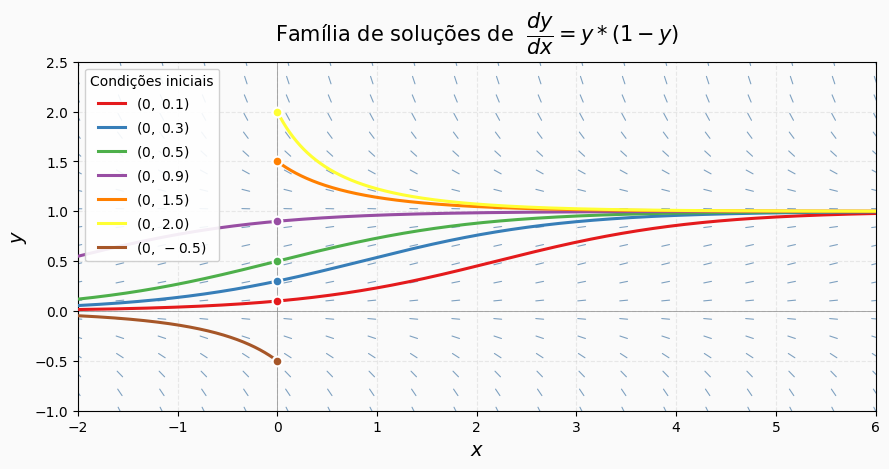

In [4]:
def plot_family(expr, xlim, ylim, density, seg_length, initial_conditions):
    """
    Desenha o campo de direções com múltiplas condições iniciais.
    
    Parâmetros:
        expr               : string com a expressão de dy/dx
        xlim, ylim         : tuplas (min, max)
        density            : densidade da grade
        seg_length         : fator de comprimento
        initial_conditions : lista de tuplas (x0, y0)
    """
    f = parse_equation(expr)
    
    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#FAFAFA')
    
    draw_direction_field(ax, f, xlim, ylim, density, seg_length)
    
    colors = plt.cm.Set1(np.linspace(0, 1, max(len(initial_conditions), 9)))
    
    for idx, (x0, y0) in enumerate(initial_conditions):
        sol_x, sol_y = solve_ode(f, x0, y0, xlim)
        if sol_x is not None:
            c = colors[idx % len(colors)]
            mask = (sol_y >= ylim[0] - 1) & (sol_y <= ylim[1] + 1)
            ax.plot(sol_x[mask], sol_y[mask],
                    color=c, linewidth=2.2, label=f'$({x0},\; {y0})$', zorder=5)
            ax.plot(x0, y0, 'o', color=c, markersize=7, zorder=6,
                    markeredgecolor='white', markeredgewidth=1.5)
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('$x$', fontsize=14)
    ax.set_ylabel('$y$', fontsize=14)
    ax.set_title(
        f'Família de soluções de  $\\dfrac{{dy}}{{dx}} = {expr}$',
        fontsize=15, pad=15
    )
    ax.axhline(0, color='#888', linewidth=0.5)
    ax.axvline(0, color='#888', linewidth=0.5)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9, title='Condições iniciais')
    plt.tight_layout()
    plt.show()


# ── Exemplo: equação logística y' = y(1 - y) ──
plot_family(
    expr='y * (1 - y)',
    xlim=(-2, 6),
    ylim=(-1, 2.5),
    density=20,
    seg_length=1.0,
    initial_conditions=[
        (0, 0.1), (0, 0.3), (0, 0.5),
        (0, 0.9), (0, 1.5), (0, 2.0),
        (0, -0.5)
    ]
)

### Exercício proposto

Modifique a chamada acima para explorar a equação $\frac{dy}{dx} = -x/y$ com condições iniciais sobre o eixo $x$ (por exemplo, $(1, 0.01)$, $(2, 0.01)$, $(3, 0.01)$). O que você observa? Que curvas conhecidas são as soluções?

---

*Caderno criado para uso didático em disciplinas de Equações Diferenciais e Métodos Numéricos.*